# Домашнє завдання: Класифікація зображень

## 1. Імпорт бібліотек та налаштування пристрою

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, models, transforms
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import os
from google.colab import userdata
import kagglehub

# 1. Фіксуємо seed для відтворюваності
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 2. Визначаємо пристрій (GPU / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Використовується пристрій: {device}")
print("Усі необхідні бібліотеки успішно імпортовано, Seed зафіксовано.")

Використовується пристрій: cpu
Усі необхідні бібліотеки успішно імпортовано, Seed зафіксовано.


## 2. Завантаження набору даних з Kaggle

In [4]:
# Безпечно отримуємо токен зі сховища Colab Secrets
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Скачуємо датасет Intel Image Classification з Kaggle
dataset_path = kagglehub.dataset_download('puneet6060/intel-image-classification')

print(f"Датасет успішно завантажено у папку: {dataset_path}")

train_dir = os.path.join(dataset_path, 'seg_train', 'seg_train')
test_dir = os.path.join(dataset_path, 'seg_test', 'seg_test')

# Перевірка наявності папок
print("Шлях до Train:", train_dir)
print("Шлях до Test:", test_dir)
print("Папка Train існує:", os.path.exists(train_dir))
print("Папка Test існує:", os.path.exists(test_dir))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Датасет успішно завантажено у папку: /kaggle/input/intel-image-classification
Шлях до Train: /kaggle/input/intel-image-classification/seg_train/seg_train
Шлях до Test: /kaggle/input/intel-image-classification/seg_test/seg_test
Папка Train існує: True
Папка Test існує: True


## 3. Попередня обробка, аугментація та створення DataLoader

- Тренувальний набір: використовуємо `RandomResizedCrop` і `RandomHorizontalFlip` для аугментації.
- Валідаційний та тестовий набори: використовуємо `CenterCrop` без випадкових модифікацій.

Розділяємо дані на навчання/валідацію та створюємо `DataLoader`.

In [6]:
# 1. Визначення трансформацій
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomResizedCrop(150, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.CenterCrop(150),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Завантаження датасетів
train_data_full = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_data_full = datasets.ImageFolder(root=train_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

# 3. Розподіл для тренувальної та валідаційної вибірки (80% / 20%)
val_size = int(0.2 * len(train_data_full))
train_size = len(train_data_full) - val_size

train_indices, val_indices = torch.utils.data.random_split(
    range(len(train_data_full)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Фіксуємо seed для відтворюваності розколу
)

train_dataset = Subset(train_data_full, train_indices.indices)
val_dataset = Subset(val_data_full, val_indices.indices)

# 4. Створення DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Виводимо дані
class_names = train_data_full.classes
print(f"Класів виявлено ({len(class_names)}): {class_names}")
print(f"\nРозміри вибірок:")
print(f"- Навчальна (Train): {len(train_dataset)} зображень ({len(train_loader)} батчів)")
print(f"- Валідаційна (Val):  {len(val_dataset)} зображень ({len(val_loader)} батчів)")
print(f"- Тестова (Test):     {len(test_dataset)} зображень ({len(test_loader)} батчів)")

Класів виявлено (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Розміри вибірок:
- Навчальна (Train): 11228 зображень (351 батчів)
- Валідаційна (Val):  2806 зображень (88 батчів)
- Тестова (Test):     3000 зображень (94 батчів)


## 4. Створення моделі (Transfer Learning: ResNet18)
Використовуємо попередньо навчену архітектуру **ResNet18** з бібліотеки `torchvision.models`.
- Заморожуємо ваги базових шарів (`requires_grad = False`), для базових візуальних ознаки.
- Модифікуємо фінальний лінійний шар (`fc`), для ймовірностей наших 6 категорій.

In [7]:
# 1. Завантажуємо попередньо навчену модель ResNet18
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Заморожуємо ваги всіх базових шарів мережі
for param in model.parameters():
    param.requires_grad = False

# 2. Модифікуємо fc під кількість наших класів
num_features = model.fc.in_features

# Замінюємо шар
model.fc = nn.Sequential(
    nn.Dropout(p=0.3), # Невеликий dropout для запобігання перенавчанню
    nn.Linear(num_features, len(class_names))
)

# Переносимо модель на обраний пристрій (у нашому випадку — CPU)
model = model.to(device)

print("Архітектуру моделі успішно змінено та перенесено на пристрій:", device)
# Виведимо змінений fc для перевірки
print("\nФінальний шар моделі:")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


Архітектуру моделі успішно змінено та перенесено на пристрій: cpu

Фінальний шар моделі:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=6, bias=True)
)


## 5. Визначення функції втрат, оптимізатора та планувальника

- Функція втрат: `nn.CrossEntropyLoss()`
- Оптимізатор: `optim.Adam` з невеликим `weight_decay` для запобігання перенавчанню. Навчаємо лише параметри фінального шару (`model.fc.parameters()`), оскільки основні шари заморожені.
- Планувальник: `StepLR` для адаптивного зменшення швидкості навчання.

### Обґрунтування вибору функції втрат (`nn.CrossEntropyLoss`)

Для задачі багатокласової класифікації (6 категорій) обрано `nn.CrossEntropyLoss` з таких причин:
1. Об'єднує перетворення logits на ймовірності та розрахунок штрафу. Тому не потрібно додавати Softmax на виході моделі.
2. Штрафує модель не просто за невірний клас, а коли модель дає високу ймовірність на хибну відповідь, це має покращити збіжність навчання.

In [8]:
# Визначаємо функцію втрат
criterion = nn.CrossEntropyLoss()

# Оптимізатор лише для нового фінального шару
learning_rate = 0.001
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate, weight_decay=1e-4)

# Планувальник швидкості навчання знижує lr на 50% кожні 3 епохи
scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

print("Функція втрат, оптимізатор та планувальник успішно ініціалізовані.")

Функція втрат, оптимізатор та планувальник успішно ініціалізовані.


## 6. Training Loop

Стандартний цикл тренування та валідації у PyTorch:
- Проходимо по епохах та батчах у `train_loader` через пряме проходження (`forward`), обчислюємо втрати (`criterion`), робимо зворотне поширення помилки (`backward`) та оновлюємо ваги через `optimizer`.
- Наприкінці кожної епохи оцінюємо модель на валідаційному наборі (`val_loader`) без оновлення вагів (`torch.no_grad()`). та зберігаємо ваги найкращої моделі.
- Оновлюємо планувальник швидкості навчання (`scheduler`).

In [9]:
import copy
from tqdm import tqdm

num_epochs = 5
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

# Історія навчання (для візуалізації)
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print(f"Починаємо навчання моделі на {num_epochs} епох...\n")

for epoch in range(num_epochs):
    print(f"Епоха {epoch + 1}/{num_epochs}")
    print("-" * 30)

    # --- Фаза 1: Training ---
    model.train()  # Переводимо модель у режим навчання
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(train_loader, desc="Тренування"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Обнуляємо градієнти перед новим кроком
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass & optimizer step
        loss.backward()
        optimizer.step()

        # Збираємо статистику
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # Розрахунок середніх метрик для train
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = float(running_corrects.double() / len(train_dataset))

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc * 100:.2f}%")

    # --- Фаза 2: Validation ---
    model.eval()  # Переводимо модель у режим оцінки
    val_running_loss = 0.0
    val_running_corrects = 0

    with torch.no_grad():  # Вимикаємо обчислення градієнтів для економії пам'яті та часу
        for inputs, labels in tqdm(val_loader, desc="Валідація"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    # Розрахунок середніх метрик для val
    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = float(val_running_corrects.double() / len(val_dataset))

    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc * 100:.2f}%\n")

    # Зберігаємо найкращі ваги моделі
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_resnet18_model.pth')
        print(">>> Збережено нову найкращу модель за точністю на валідації!\n")

    # Робимо крок планувальника швидкості навчання
    scheduler.step()

print(f"Навчання завершено! Найвища точність на валідації (Best Val Acc): {best_acc * 100:.2f}%")

# Завантажуємо найкращі ваги назад у модель для подальшого тестування
model.load_state_dict(best_model_wts)

Починаємо навчання моделі на 5 епох...

Епоха 1/5
------------------------------


Тренування: 100%|██████████| 351/351 [09:32<00:00,  1.63s/it]


Train Loss: 0.6664 | Train Acc: 76.45%


Валідація: 100%|██████████| 88/88 [02:09<00:00,  1.47s/it]


Val Loss:   0.3554 | Val Acc:   87.67%

>>> Збережено нову найкращу модель за точністю на валідації!

Епоха 2/5
------------------------------


...

Тренування: 100%|██████████| 351/351 [09:05<00:00,  1.55s/it]


Train Loss: 0.3985 | Train Acc: 85.30%


Валідація: 100%|██████████| 88/88 [02:03<00:00,  1.41s/it]

Val Loss:   0.2922 | Val Acc:   89.27%

>>> Збережено нову найкращу модель за точністю на валідації!

Навчання завершено! Найвища точність на валідації (Best Val Acc): 89.27%


<All keys matched successfully>

## 7. Оцінка моделі на тестовому наборі та розрахунок метрик
Проводимо фінальне тестування завантаженої найкращої моделі на незалежному тестовому наборі (`test_loader`).
- Обчислюємо Accuracy та F1-score.
- Формуємо класифікаційний звітдля кожного з 6 класів.

In [11]:
# Переводимо модель в режим оцінки
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Тестування"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Конвертуємо у масиви numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Обчислюємо метрики
test_accuracy = accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average='macro')
test_f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print(f"\n--- РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ ---")
print(f"Accuracy: {test_accuracy * 100:.2f}%")
print(f"F1-score (Macro):    {test_f1_macro:.4f}")
print(f"F1-score (Weighted): {test_f1_weighted:.4f}\n")

# Детальний звіт по кожному класу
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Тестування: 100%|██████████| 94/94 [02:17<00:00,  1.47s/it]


--- РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ ---
Accuracy: 89.30%
F1-score (Macro):    0.8953
F1-score (Weighted): 0.8926

Classification Report:
              precision    recall  f1-score   support

   buildings       0.92      0.90      0.91       437
      forest       0.98      0.98      0.98       474
     glacier       0.80      0.85      0.83       553
    mountain       0.86      0.78      0.82       525
         sea       0.90      0.95      0.93       510
      street       0.91      0.92      0.92       501

    accuracy                           0.89      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.89      0.89      0.89      3000



### Аналіз результатів та помилок моделі

1. Найкраще розпізнані класи:
   * `forest` (F1 = 0.98), `sea` (0.93), `street` (0.92): Тому що ці категорії мають унікальні глобальні текстури та колір (зелений для лісу, блакитна для води, і більш-менш чіткі лінії для доріг).

2. Найбільш проблемні класи:
   * `glacier` (F1 = 0.83) та `mountain` (F1 = 0.82): Модель плутає гори з льодовиками, тому що вони візуально схожі (біло-сірі, зі снігом, і у просторі вони мають схожі форми - не так як вода (пласка поверхня) або ліс (є вертикальна структура)). Тут навколишній ландшаф відіграє роль для розпізнавання цих проблемних класів.

Висновки: Повністю заморожений бекбон ResNet18 гарно впорався із загальними ознаками, але для диференціації схожих природних ландшафтів (гори/льодовики) бракує адаптації внутрішніх шарів.


## 8. Візуалізація результатів (Матриця помилок)
Будуємо `Confusion Matrix` за допомогою бібліотеки `seaborn`. Це дозволить наочно побачити, які саме класи модель плутає найчастіше (наприклад, гори та льодовики).

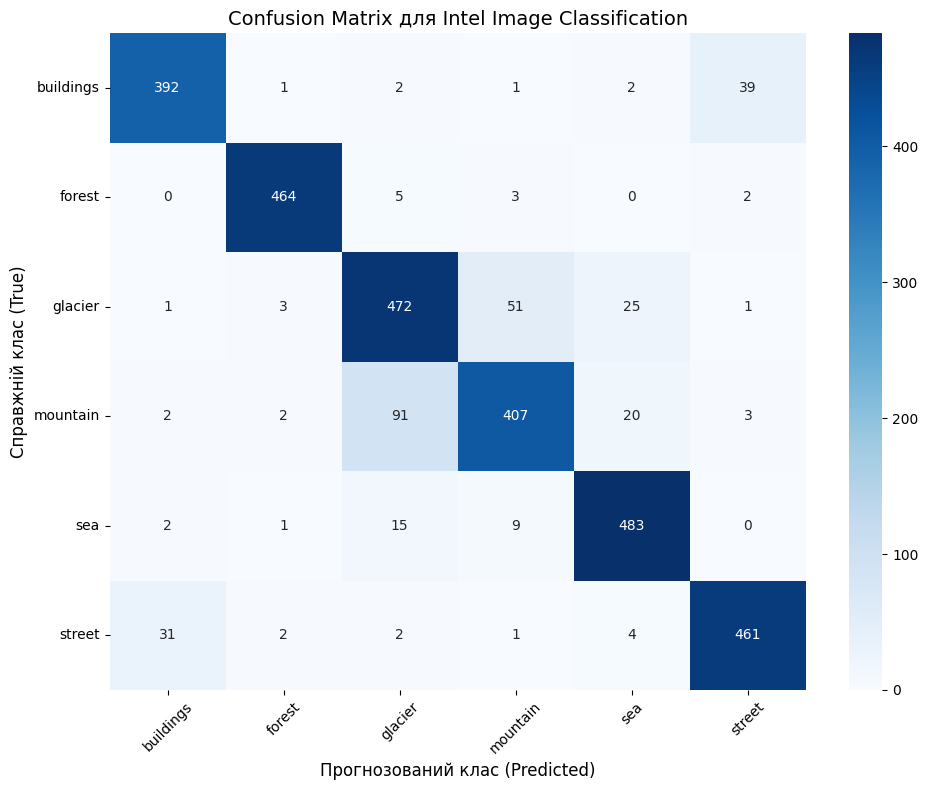

In [12]:
# Обчислюємо матрицю помилок
cm = confusion_matrix(all_labels, all_preds)

# Візуалізуємо за допомогою heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Прогнозований клас (Predicted)', fontsize=12)
plt.ylabel('Справжній клас (True)', fontsize=12)
plt.title('Confusion Matrix для Intel Image Classification', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

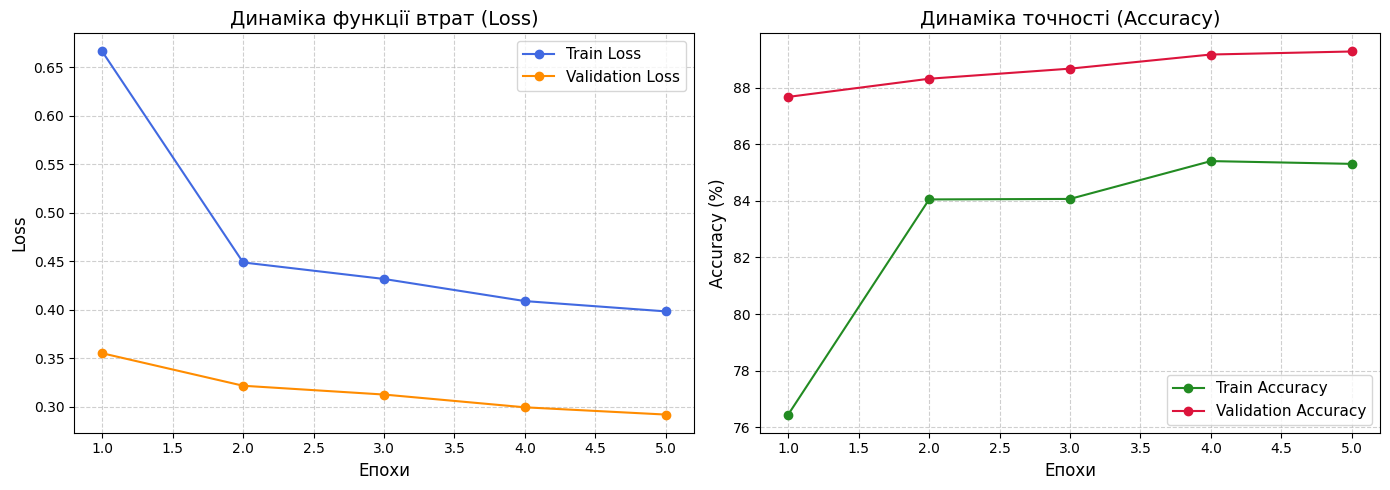

In [16]:
# Побудова графіків кривих навчання за збереженою історією
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Графік 1: Функція втрат (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o', color='darkorange')
plt.title('Динаміка функції втрат (Loss)', fontsize=14)
plt.xlabel('Епохи', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Графік 2: Точність (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Train Accuracy', marker='o', color='forestgreen')
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Validation Accuracy', marker='o', color='crimson')
plt.title('Динаміка точності (Accuracy)', fontsize=14)
plt.xlabel('Епохи', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Висновки щодо кривих навчання

* Графіки функції втрат (`Loss`) показують монотонне зниження як на навчальному, так і на валідаційному наборах даних протягом усіх 5 епох, що свідчить про коректно підібраний `learning_rate`.
* Валідаційна точність стабільно тримається на високому рівні (досягаючи ~89.3%), що підтверджує ефективність вагів з ResNet18.

### Шляхи покращення моделі

Для оптимізації нашої моделі можна розглянути такі підходи:
1. **Full Fine-Tuning:** Розморожування всіх шарів мережі. Дає максимальну адаптацію, але вимагає багато часу та несе ризик перенавчання.
2. **Partial Fine-Tuning:** Розморожування лише останніх глибоких блоків (наприклад, `layer4`) разом із класифікатором. Дозволяє налаштувати високорівневі ознаки, зберігаючи універсальні фільтри ранніх шарів.
3. **Розширення аугментації даних:** Додавання складніших перетворень (зміна яскравості, контрасту, повороти) для підвищення стійкості моделі.

---

### Що ми обираємо та чому

Для нашого експерименту ми обираємо часткове донавчання (`layer4` + `fc`) із застосуванням зниженого `learning_rate` ($10^{-4}$).

**Обґрунтування вибору:**
* **Виправлення специфічних помилок:** На попередньому етапі (Feature Extraction) модель досягла 89.3% точності, але плутала схожі класи (`mountain` і `glacier`). Розморожування `layer4` дозволить адаптувати глибокі фільтри під текстури конкретно нашого датасету.
* Оскільки ми обмежені в ресурсах та часі, повне розморожування могло б зруйнувати вже готові ваги ImageNet. Частковий тюнінг із меншим `lr` має забезпечити покращення якості без ризику перенавчання.

## 9. Експеримент

In [13]:
# 1. Розморожуємо layer4 та fc, а решту залишаємо замороженими
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Перевіряємо, які шари тепер доступні для навчання
print("Статус параметрів шарів для Fine-Tuning:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  - {name}: Навчається (requires_grad=True)")

# 2. Налаштовуємо оптимізатор з меншим learning rate
fine_tune_lr = 1e-4
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': fine_tune_lr},
    {'params': model.fc.parameters(), 'lr': fine_tune_lr * 2}
], weight_decay=1e-4)

# Новий планувальник
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

# 3. Запускаємо додаткові епохи fine-tuning
additional_epochs = 3
print(f"\nПочинаємо Fine-Tuning на {additional_epochs} епохи...")

for epoch in range(additional_epochs):
    print(f"\nFine-Tuning Епоха {epoch + 1}/{additional_epochs}")
    print("-" * 30)

    # --- Тренування ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(train_loader, desc="Fine-Tuning Тренування"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_dataset)
    train_acc = float(running_corrects.double() / len(train_dataset))
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}%")

    # --- Валідація ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Fine-Tuning Валідація"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = float(val_running_corrects.double() / len(val_dataset))
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc * 100:.2f}%")

    scheduler.step()

print("\nFine-Tuning успішно завершено!")

Статус параметрів шарів для Fine-Tuning:
  - layer4.0.conv1.weight: Навчається (requires_grad=True)
  - layer4.0.bn1.weight: Навчається (requires_grad=True)
  - layer4.0.bn1.bias: Навчається (requires_grad=True)
  - layer4.0.conv2.weight: Навчається (requires_grad=True)
  - layer4.0.bn2.weight: Навчається (requires_grad=True)
  - layer4.0.bn2.bias: Навчається (requires_grad=True)
  - layer4.0.downsample.0.weight: Навчається (requires_grad=True)
  - layer4.0.downsample.1.weight: Навчається (requires_grad=True)
  - layer4.0.downsample.1.bias: Навчається (requires_grad=True)
  - layer4.1.conv1.weight: Навчається (requires_grad=True)
  - layer4.1.bn1.weight: Навчається (requires_grad=True)
  - layer4.1.bn1.bias: Навчається (requires_grad=True)
  - layer4.1.conv2.weight: Навчається (requires_grad=True)
  - layer4.1.bn2.weight: Навчається (requires_grad=True)
  - layer4.1.bn2.bias: Навчається (requires_grad=True)
  - fc.1.weight: Навчається (requires_grad=True)
  - fc.1.bias: Навчається (req

Fine-Tuning Тренування: 100%|██████████| 351/351 [12:29<00:00,  2.13s/it]


Train Loss: 0.3103 | Train Acc: 89.43%


Fine-Tuning Валідація: 100%|██████████| 88/88 [02:08<00:00,  1.46s/it]


Val Loss:   0.2385 | Val Acc:   92.12%

Fine-Tuning Епоха 2/3
------------------------------


...

Val Loss:   0.2206 | Val Acc:   92.84%

Fine-Tuning Епоха 3/3
------------------------------


Fine-Tuning Тренування: 100%|██████████| 351/351 [12:47<00:00,  2.19s/it]


Train Loss: 0.1388 | Train Acc: 94.91%


Fine-Tuning Валідація: 100%|██████████| 88/88 [02:08<00:00,  1.46s/it]

Val Loss:   0.2089 | Val Acc:   93.44%

Fine-Tuning успішно завершено!


## 10. Фінальна оцінка моделі на тестовому наборі (після Fine-Tuning)

Фінальне тестування (Fine-Tuning): 100%|██████████| 94/94 [02:19<00:00,  1.48s/it]



--- РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ ПІСЛЯ FINE-TUNING ---
Accuracy: 93.00%
F1-score (Macro):    0.9315
F1-score (Weighted): 0.9298

Класифікаційний звіт (Classification Report) після Fine-Tuning:
              precision    recall  f1-score   support

   buildings       0.94      0.92      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.91      0.85      0.88       553
    mountain       0.87      0.91      0.89       525
         sea       0.95      0.97      0.96       510
      street       0.93      0.95      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



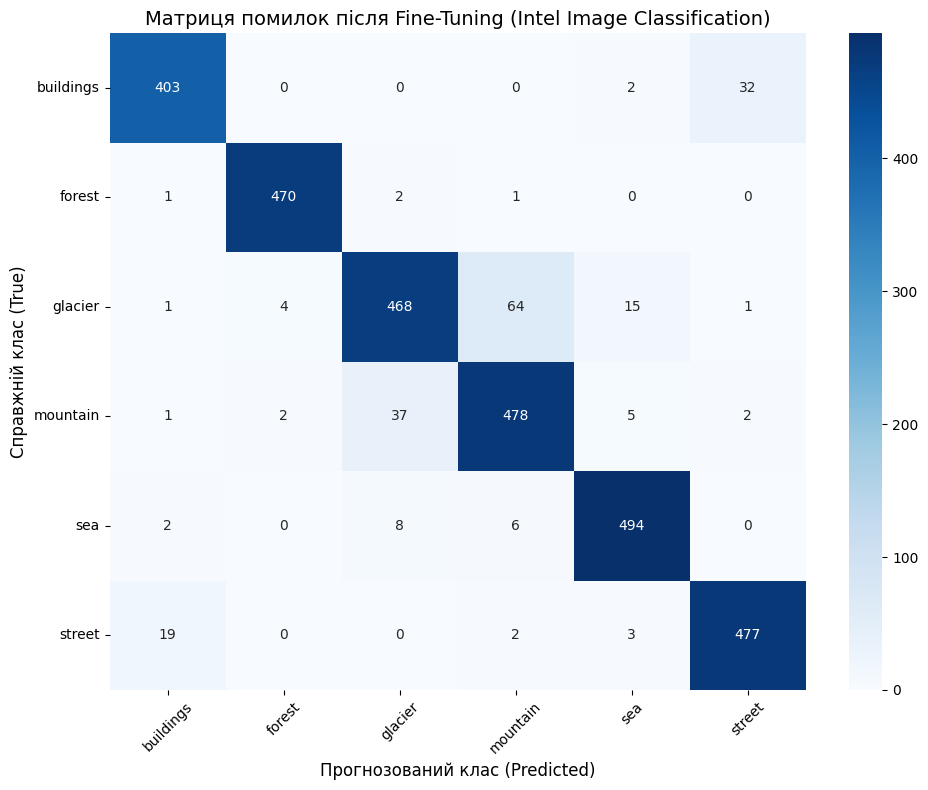

In [15]:
# Переводимо модель в режим оцінки
model.eval()

all_preds_ft = []
all_labels_ft = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Фінальне тестування (Fine-Tuning)"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(labels.cpu().numpy())

# Конвертуємо у масиви numpy
all_preds_ft = np.array(all_preds_ft)
all_labels_ft = np.array(all_labels_ft)

# Обчислюємо метрики
ft_accuracy = accuracy_score(all_labels_ft, all_preds_ft)
ft_f1_macro = f1_score(all_labels_ft, all_preds_ft, average='macro')
ft_f1_weighted = f1_score(all_labels_ft, all_preds_ft, average='weighted')

print(f"\n--- РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ ПІСЛЯ FINE-TUNING ---")
print(f"Accuracy: {ft_accuracy * 100:.2f}%")
print(f"F1-score (Macro):    {ft_f1_macro:.4f}")
print(f"F1-score (Weighted): {ft_f1_weighted:.4f}\n")

# Детальний звіт по кожному класу
print("Класифікаційний звіт (Classification Report) після Fine-Tuning:")
print(classification_report(all_labels_ft, all_preds_ft, target_names=class_names))

# Побудова матриці помилок для порівняння
cm_ft = confusion_matrix(all_labels_ft, all_preds_ft)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Прогнозований клас (Predicted)', fontsize=12)
plt.ylabel('Справжній клас (True)', fontsize=12)
plt.title('Матриця помилок після Fine-Tuning (Intel Image Classification)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Аналіз основного тренування та додаткового Fine-Tuning

1. **Базовий етап:**
   * Застосовано попередньо навчену модель ResNet18 із повністю замороженою згортковою основою.
   * Досягнуто базову тестову точність **89.30%** (F1-score: 0.8953).
   * Основна проблема: модель плутала схожі природні ландшафти: гори (`mountain`) та льодовики (`glacier`).

2. **Оптимізація:**
   * Розморожено останній згортковий блок (`layer4`) та класифікатор (`fc`) для кращого диференціювання ознак.
   * Виконано 3 додаткові епохи навчання зі зниженим `learning_rate` ($10^{-4}$).
   * Accuracy): зросла до **93.00%**.
   * Покращилася диференціація складних класів для льодовиків (`glacier`) F1 зріс з 0.83 до 0.88, а для гір (`mountain`) з 0.82 до 0.89.

## Візуалізація помилок моделі
Виводимо приклади зображень з тестового набору, на яких донавчена модель зробила помилки. Це допоможе наочно побачити, що саме мережа плутає.

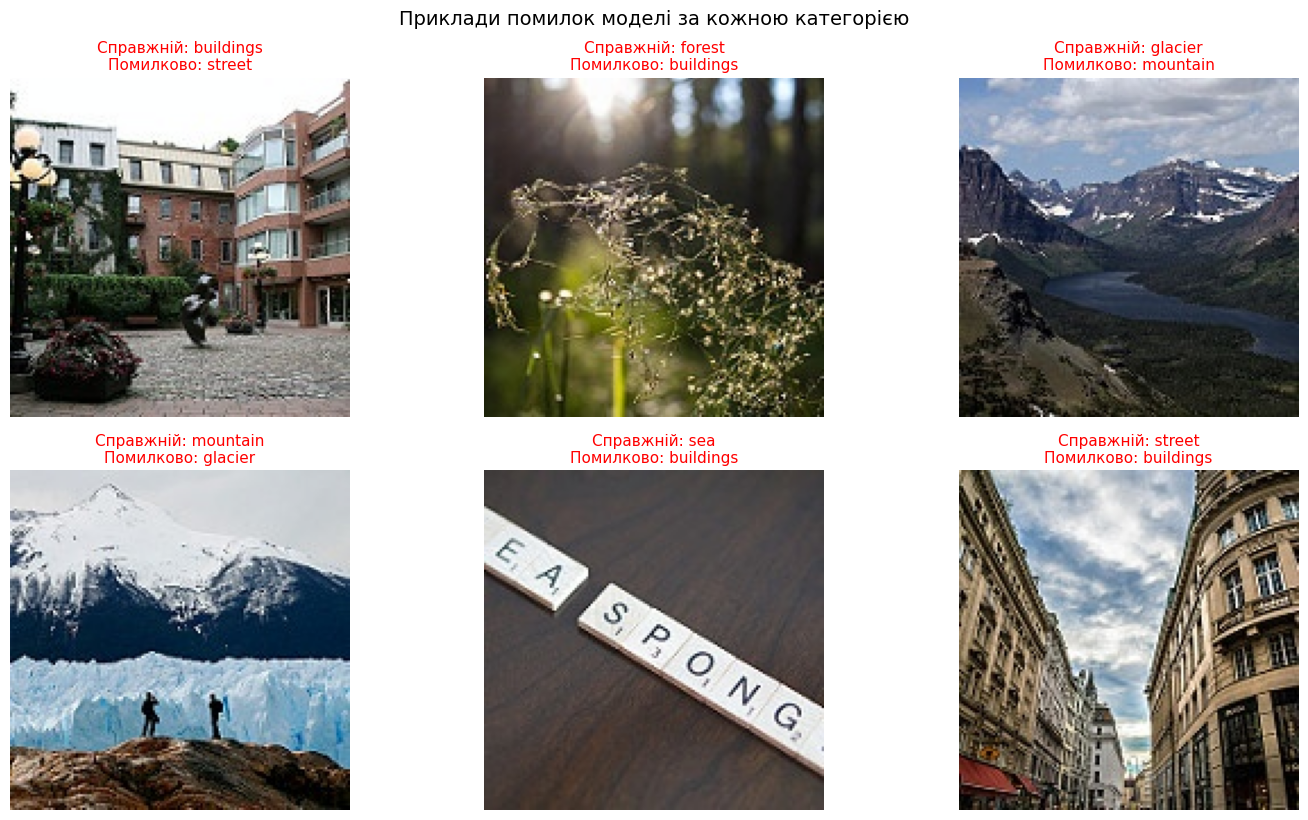

In [18]:
model.eval()
errors_by_class = {}
target_classes_count = len(class_names)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_dev = inputs.to(device)
        labels_dev = labels.to(device)

        outputs = model(inputs_dev)
        _, preds = torch.max(outputs, 1)

        mask = preds != labels_dev
        if mask.any():
            for img, true_l, pred_l in zip(inputs[mask], labels_dev[mask], preds[mask]):
                t_idx = true_l.item()
                p_idx = pred_l.item()

                # Зберігаємо першу знайдену помилку для кожного справжнього класу
                if t_idx not in errors_by_class:
                    errors_by_class[t_idx] = (img, t_idx, p_idx)

                if len(errors_by_class) >= target_classes_count:
                    break
        if len(errors_by_class) >= target_classes_count:
            break

# Візуалізація у вигляді сітки 2х3
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(15, 8))
# Сортуємо за індексом класу
sorted_errors = sorted(errors_by_class.items())

for i, (t_idx, (img, true_l, pred_l)) in enumerate(sorted_errors):
    img_np = img.numpy().transpose((1, 2, 0))
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_np)
    true_name = class_names[true_l]
    pred_name = class_names[pred_l]
    plt.title(f"Справжній: {true_name}\nПомилково: {pred_name}", color='red', fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Приклади помилок моделі за кожною категорією", fontsize=14, y=1.02)
plt.show()

### Висновки з Error Analysis

* Модель плутає категорії зі схожими текстурами та контекстом: наприклад, гори (`mountain`) і льодовики (`glacier`), а також міські пейзажі (`buildings` і `street`).

* Візуальна перевірка виявила аномалії розмітки в датасеті (настільна гра зі словом SEA у категорії `sea`), що пояснює частину хибних спрацьовувань моделі.